# Calibration Success Rate

This notebook loads calibration annotations from the SQLite database, compares each annotator's answers with the golden annotations, and visualizes per-user success rates.

It reports two metrics:
- **Coarse label success**: `negative` vs `positive`
- **Exact choice success**: exact UI choice match among `negative`, `positive_not_localizable`, and `positive_localizable`

This notebook does not score span quality yet.

In [1]:
from pathlib import Path
import json
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')


def find_project_root(start=None):
    start_path = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start_path, *start_path.parents]:
        if (candidate / 'pyproject.toml').exists():
            return candidate
    raise FileNotFoundError('Could not locate project root containing pyproject.toml.')


def ui_choice_to_label(ui_choice):
    return 'negative' if ui_choice == 'negative' else 'positive'


PROJECT_ROOT = find_project_root()
DB_PATH = PROJECT_ROOT / 'annotations.db'

if not DB_PATH.exists():
    raise FileNotFoundError(
        f'Database not found at {DB_PATH}. Update DB_PATH in this notebook if your database lives elsewhere.'
    )

DB_PATH

PosixPath('/home/vladislavstankov/Projects/Python/overlap-annotations/annotations.db')

In [2]:
query = '''
SELECT
    a.id AS annotation_id,
    a.sample_id,
    a.user_id,
    u.display_name,
    a.label AS answer_label,
    a.annotation_data,
    a.created_at,
    s.sort_order,
    s.audio_path,
    s.golden_annotation
FROM annotations a
JOIN samples s ON s.id = a.sample_id
JOIN users u ON u.id = a.user_id
WHERE s.sample_type = 'calibration'
  AND a.status = 'accepted'
ORDER BY u.display_name, s.sort_order, a.created_at
'''

with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql_query(query, conn)

if df.empty:
    raise ValueError('No accepted calibration annotations found in the database.')

df['answer'] = df['annotation_data'].map(json.loads)
df['golden'] = df['golden_annotation'].map(json.loads)
df['answer_ui_choice'] = df['answer'].map(lambda item: item.get('ui_choice'))
df['gold_ui_choice'] = df['golden'].map(lambda item: item.get('ui_choice'))
df['gold_label'] = df['gold_ui_choice'].map(ui_choice_to_label)
df['coarse_match'] = df['answer_label'] == df['gold_label']
df['exact_match'] = df['answer_ui_choice'] == df['gold_ui_choice']

df[['display_name', 'sample_id', 'answer_ui_choice', 'gold_ui_choice', 'coarse_match', 'exact_match']]

,display_name,sample_id,answer_ui_choice,gold_ui_choice,coarse_match,exact_match
0,TestUser,1907,negative,negative,True,True
1,TestUser,1908,negative,negative,True,True
2,TestUser,1909,negative,positive_localizable,False,False
3,TestUser,1910,negative,positive_localizable,False,False
4,TestUser,1911,negative,negative,True,True
5,TestUserNew,1907,negative,negative,True,True
6,TestUserNew,1908,positive_not_localizable,negative,False,False
7,TestUserNew,1909,negative,positive_localizable,False,False
8,TestUserNew,1910,negative,positive_localizable,False,False
9,TestUserNew,1911,positive_not_localizable,negative,False,False


In [3]:
user_summary = (
    df.groupby(['user_id', 'display_name'], as_index=False)
    .agg(
        answered=('annotation_id', 'count'),
        coarse_correct=('coarse_match', 'sum'),
        exact_correct=('exact_match', 'sum'),
    )
)

user_summary['coarse_success_rate'] = 100 * user_summary['coarse_correct'] / user_summary['answered']
user_summary['exact_success_rate'] = 100 * user_summary['exact_correct'] / user_summary['answered']

user_summary = user_summary.sort_values(
    ['exact_success_rate', 'coarse_success_rate', 'display_name'],
    ascending=[False, False, True],
).reset_index(drop=True)

user_summary

,user_id,display_name,answered,coarse_correct,exact_correct,coarse_success_rate,exact_success_rate
0,2,TestUser,5,3,3,60.0,60.0
1,3,TestUserNew,5,1,1,20.0,20.0


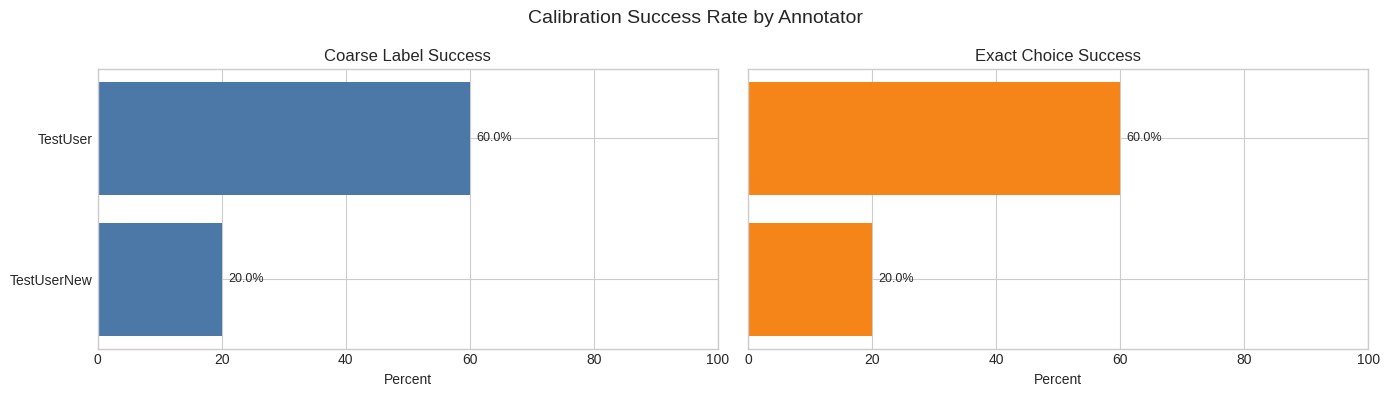

In [4]:
plot_df = user_summary.sort_values('exact_success_rate')
fig_height = max(4, 0.65 * len(plot_df))
fig, axes = plt.subplots(1, 2, figsize=(14, fig_height), sharey=True)

axes[0].barh(plot_df['display_name'], plot_df['coarse_success_rate'], color='#4c78a8')
axes[0].set_title('Coarse Label Success')
axes[0].set_xlabel('Percent')
axes[0].set_xlim(0, 100)

axes[1].barh(plot_df['display_name'], plot_df['exact_success_rate'], color='#f58518')
axes[1].set_title('Exact Choice Success')
axes[1].set_xlabel('Percent')
axes[1].set_xlim(0, 100)

for ax, column in zip(axes, ['coarse_success_rate', 'exact_success_rate']):
    for idx, value in enumerate(plot_df[column]):
        ax.text(min(value + 1, 98), idx, f'{value:.1f}%', va='center', fontsize=9)

fig.suptitle('Calibration Success Rate by Annotator', fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
mismatches = df.loc[
    ~df['exact_match'],
    ['display_name', 'sample_id', 'sort_order', 'gold_ui_choice', 'answer_ui_choice', 'created_at']
].sort_values(['display_name', 'sort_order'])

mismatches

,display_name,sample_id,sort_order,gold_ui_choice,answer_ui_choice,created_at
2,TestUser,1909,3,positive_localizable,negative,2026-04-20 02:41:26
3,TestUser,1910,4,positive_localizable,negative,2026-04-20 02:41:28
6,TestUserNew,1908,2,negative,positive_not_localizable,2026-04-20 07:18:15
7,TestUserNew,1909,3,positive_localizable,negative,2026-04-20 07:18:17
8,TestUserNew,1910,4,positive_localizable,negative,2026-04-20 07:18:20
9,TestUserNew,1911,5,negative,positive_not_localizable,2026-04-20 07:18:25
